# Feature selection (selección de variables)

Es una etapa fundamental del proceso de aprendizaje automático (Machine Learning) cuyo objetivo es **elegir, entre todas las variables disponibles, aquellas que son más relevantes o útiles para predecir el resultado** o realizar la tarea de interés (clasificación, regresión, etc.)(variable de predicción). Incluir variables irrelevantes afecta negativamente el desempeño de los modelos preditivos porque les inducen a detectar "patrones" basados en aspectos irrelevantes (mayor probabilidad de sobreajuste en los modelos).

**Objetivos principales:**

- Mejorar el rendimiento del modelo
     - Eliminar variables irrelevantes reduce el sobreajuste (overfitting).
    
     - Aumenta la capacidad de generalización.

- Reducir la complejidad computacional

    - Menos variables → entrenamiento más rápido → menor consumo de memoria.

- Facilitar la interpretabilidad

    - Un modelo con menos variables es más fácil de entender y explicar.

Además, eliminar variables innecesarias o redundantes implica otras ventajas:

- Simplificación de la descripción de cada observación/ejemplo.
Modelos complejos se sobreajustan con mayor facilidad.
- Tiempo de entrenamiento menor (hay menos datos que procesar)

## Enfoques

### Filtrado a priori (filtering)

Evalúan la relación estadística entre cada variable y la variable objetivo, independientemente del modelo. Las técnicas de filtrado previo buscan eliminar las variables innecesarias **antes** de emplear los ejemplos/observaciones para entrenar el modelo predictivo.

Estás técnicas son computacionalmente menos costosas que las técnicas wrapper pero implican las siguientes desventajas:

- No toman en cuenta las caracterísicas del modelo y, por lo tanto, existe la posiblidad de excluir variables que puedan ser útiles
- No capturan interacciones entre variables como situaciones de **multicolinealidad** que pueden tener efectos negativos en modelos de regresión/clasificación.

Por lo tanto, se recomienda emplearlas de manera conservadora o evaluar los resultados obtenidos con diferentes conjuntos de variables contra una __[linea base](https://en.wikipedia.org/wiki/Kitchen_sink_regression)__ en la que se emplean todas las variables.

**Ejemplos:**
- Correlación de Pearson
- Pruebas de chi-cuadrado (χ²)
- Información mutua (mutual information)
- ANOVA F-test

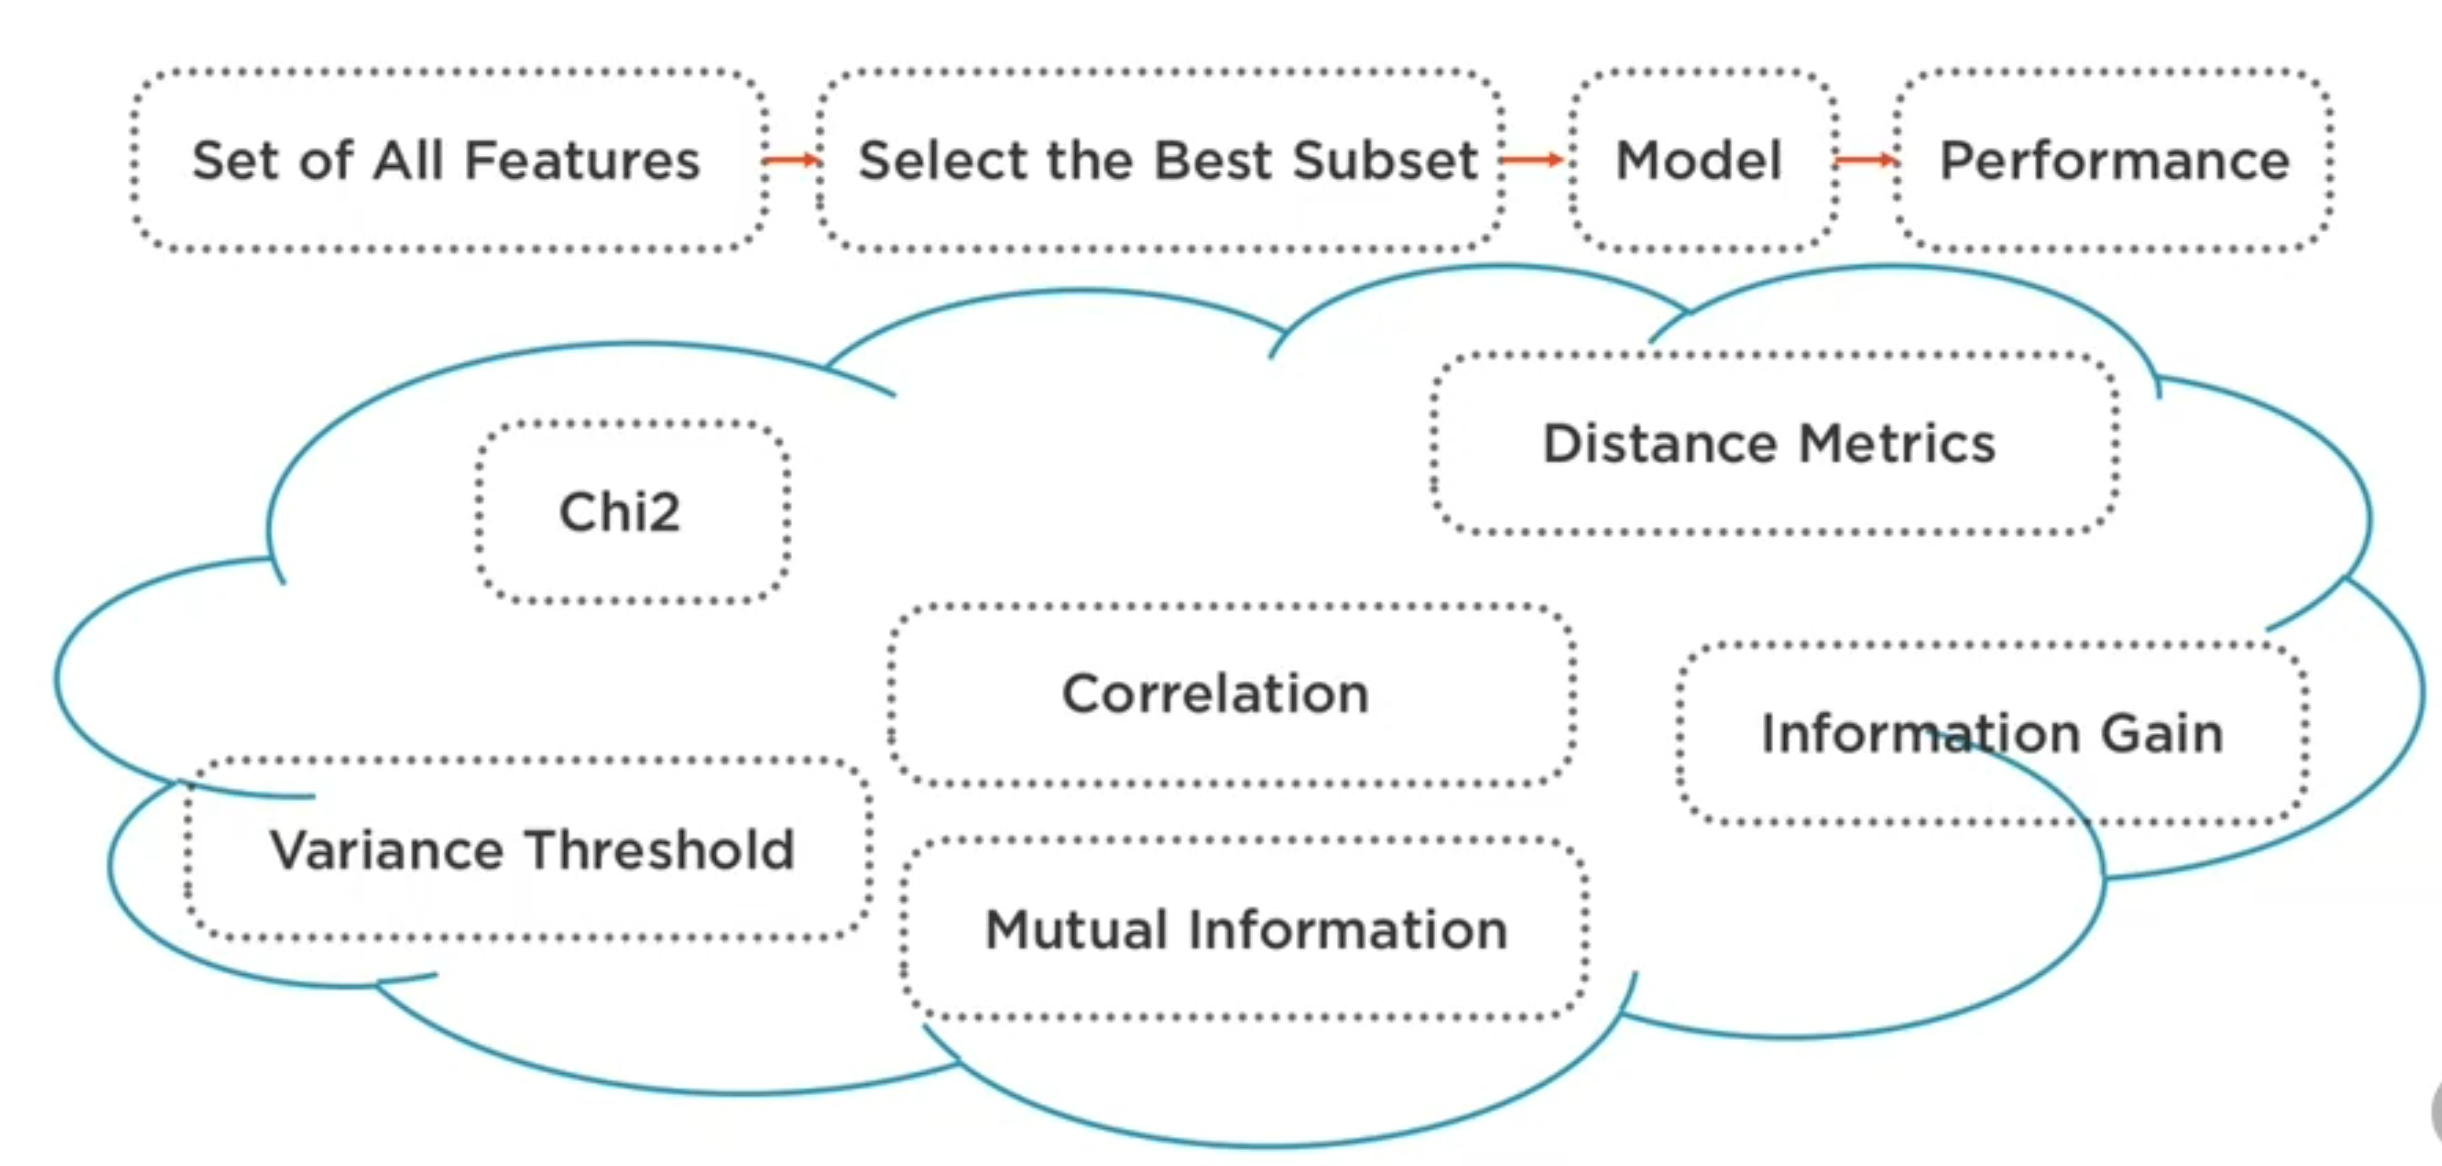

### Wrapper

Estas técnicas buscan eliminar las variables innecesarias **después** de emplear los ejemplos/observaciones para entrenar el modelo predictivo y en función de su efecto en el desempeño del mismo. La idea es quedarnos con el subconjunto de las variables que maximizen el desempeño del modelo.

Ejemplos:

- Forward Selection (se añaden variables una a una)
- Backward Elimination (se eliminan variables una a una)
- Recursive Feature Elimination (Entrena un modelo, evalúa qué variables son más importantes, elimina la menos útil y repite hasta quedarte con el número deseado de características.). Paso a paso:
    - Entrena un modelo base (por ejemplo, una regresión logística, un árbol, un SVM, etc.) usando todas las variables.
    - Evalúa la importancia de cada variable según el modelo:
    - En modelos lineales: usa los coeficientes.
    - En modelos basados en árboles: usa la importancia de las divisiones.
    - Elimina la variable menos importante.
    - Repite el proceso entrenando nuevamente el modelo con las variables restantes.
    - Continúa hasta alcanzar el número deseado de características.

**Desventajas**
- Computacionalmente costosos

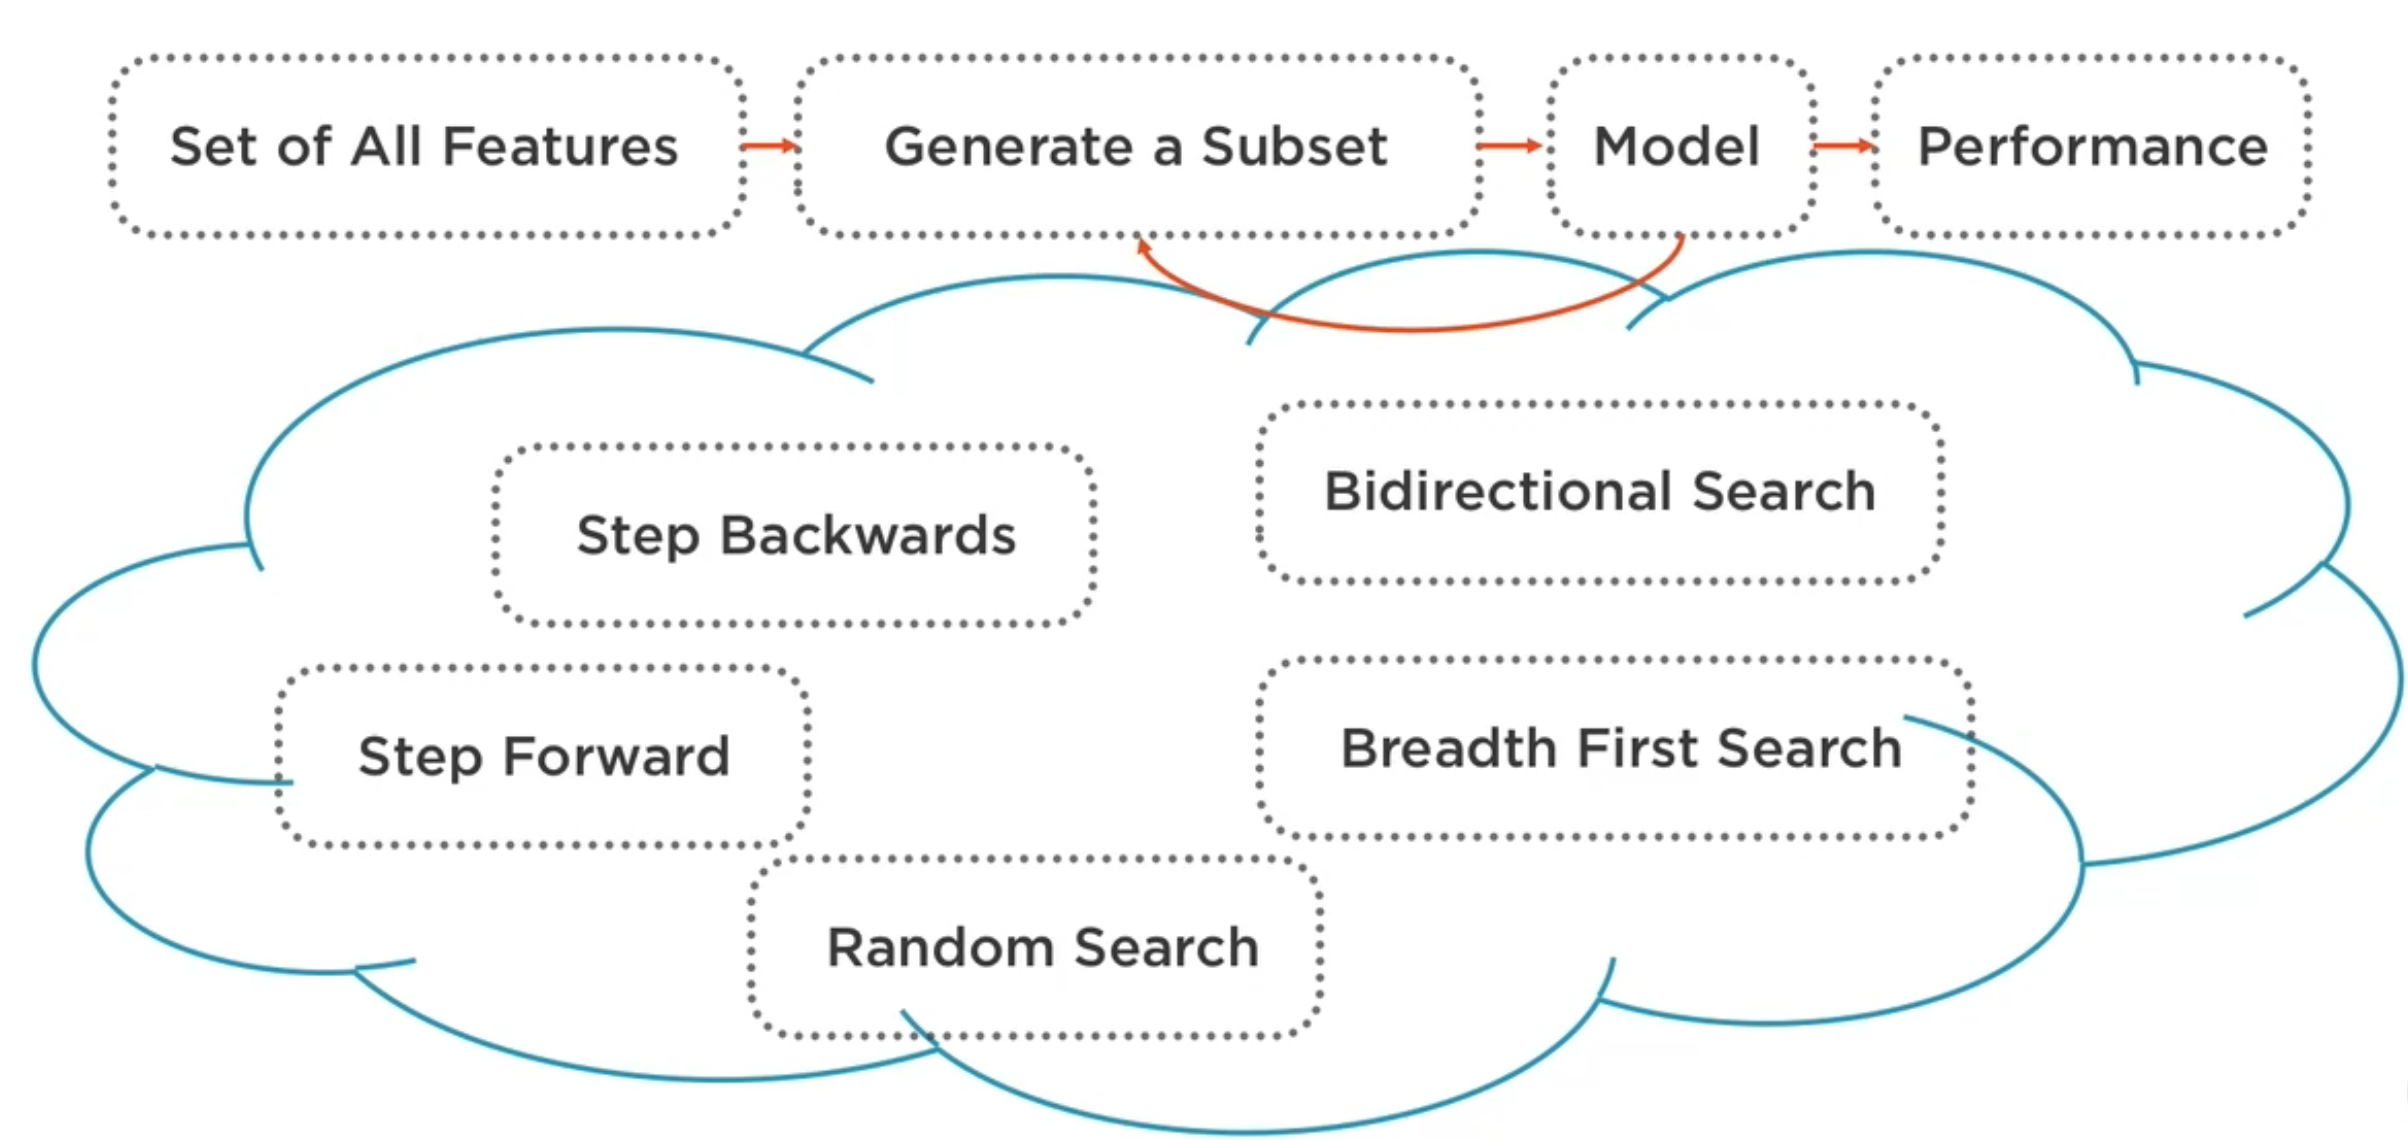

### Incrustados (Embedded)

Se realiza la selección de las variables como parte del proceso de entrenamiento del modelo. Por ejemplo, en los modelos de clasificación basados en árboles de decisión, el algoritmo que construye el árbol incopora la selección de las variables que clasifican la mayor cantidad de ejemplos.

**Desventajas**
- Dependientes del modelo

### Ejemplo práctico

Supón que tienes un dataset con 100 variables para predecir si un cliente comprará un producto.
Después del feature selection, descubres que solo 15 variables (como edad, ingresos, historial de compras, etc.) realmente aportan información útil.
Con ellas, el modelo:

- Aprende más rápido
- Tiene mejor desempeño
- Es más fácil de interpretar

## Técnicas de filtrado a priori

- __[Prueba chi cuadrado](https://es.wikipedia.org/wiki/Prueba_%CF%87%C2%B2_de_Pearson)__ Para cada variable `X`, emplear la prueba para determinar si dicha variable y `Y` son independientes. Si lo son, eliminar `X`. Si por el contrario, cambios en la variable `X` provocan cambios significativos en el valor esperado de la variable `Y`, `X` se considera significativa. **Se aplica cuando `Y` es una variable categórica (clasificación)**
- __[Información mutua](https://es.wikipedia.org/wiki/Informaci%C3%B3n_mutua)__ determina la dependencia mutua de dos variables midiendo la reducción de la incertidumbre (entropía) de una variable aleatoria `X`, debido al conocimiento del valor de otra variable aleatoria `Y`. Un valor elevado es una indicación de que una variable tiene gran influencia en la otra, cero indica que son  independientes. **Se considera una técnica superior a ANOVA (Analysis of Variance) por su capacidad capturar relaciones no lineales**.

## Prueba Chi cuadrado

In [22]:
import polars as pl

In [23]:
df = pl.read_csv("diabetes.csv")
df

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome
i64,i64,i64,i64,i64,f64,f64,i64,i64
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1
…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,0
2,122,70,27,0,36.8,0.34,27,0
5,121,72,23,112,26.2,0.245,30,0


### Selección de variables con SelectKBest y Polars

Dado que `scikit-learn` no soporta Polars directamente, debemos extraer los valores como arrays de NumPy o convertir a Pandas. Una vez realizada la selección, podemos usar las máscaras de `get_support()` para filtrar las columnas originales en Polars.

El método `get_support()` es fundamental en los selectores de variables de `scikit-learn` (como `SelectKBest`).

Funciona de la siguiente manera:

1. **Máscara booleana:** Devuelve un arreglo (array) de valores booleanos (`True` o `False`).
2. **Correspondencia:** Cada posición en el arreglo corresponde a una columna (variable) del conjunto de datos original `X` que pasaste al método `.fit()`.
3. **Selección:** Un valor `True` indica que la variable fue seleccionada por el algoritmo (porque cumplió con los criterios estadísticos), mientras que `False` indica que fue descartada.

En el ejemplo, `zip(X_pl.columns, selector.get_support())` empareja el nombre de cada columna con su resultado booleano y así filtrar solo los nombres de las columnas que 'sobrevivieron' a la selección.

In [24]:
# 1. Separar variables (X) y objetivo (y)
# Convertimos a numpy para que sklearn lo procese
X_pl = df.drop("Outcome")
y_pl = df["Outcome"].to_numpy()

In [25]:
#chi2 determina si cada X,y son indepedientes; 'y' debe ser una variable categórica.
#SelectKBest emplea la función chi2 para probar cada (X,y) y seleccionar las K mejores variables
#https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html
from sklearn.feature_selection import chi2, SelectKBest

# 2. Configurar y aplicar SelectKBest
# Usamos k=4 como ejemplo
selector = SelectKBest(score_func=chi2, k=3)
selector.fit(X_pl.to_numpy(), y_pl)

SelectKBest(k=3, score_func=<function chi2 at 0x7872140ae980>)

In [26]:
# 3. Obtener los nombres de las columnas seleccionadas
# 'get_support()' nos da un booleano para cada columna original
selected_columns = [col for col, selected in zip(X_pl.columns, selector.get_support()) if selected]

In [27]:
# 4. Crear el nuevo DataFrame en Polars con las variables elegidas
df_selected = X_pl.select(selected_columns)

print(f"Variables seleccionadas: {selected_columns}")
display(df_selected.head())

Variables seleccionadas: ['Glucose', 'Insulin', 'Age']


Glucose,Insulin,Age
i64,i64,i64
148,0,50
85,0,31
183,0,32
89,94,21
137,168,33


## Información mutua

In [28]:
df = pl.read_csv("diabetes.csv")
df

Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BodyMassIndex,DiabetesPedigreeFunction,Age,Outcome
i64,i64,i64,i64,i64,f64,f64,i64,i64
6,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
8,183,64,0,0,23.3,0.672,32,1
1,89,66,23,94,28.1,0.167,21,0
0,137,40,35,168,43.1,2.288,33,1
…,…,…,…,…,…,…,…,…
10,101,76,48,180,32.9,0.171,63,0
2,122,70,27,0,36.8,0.34,27,0
5,121,72,23,112,26.2,0.245,30,0


In [29]:
X_pl = df.drop("Outcome")
y_pl = df["Outcome"].to_numpy()

In [30]:
# mutual_info_classif determina si cada X,y son indepedientes.
# Si 'y' es una variable numérica contínua se debe usar mutual_info_regression.
# SelectPercentile emplea mutual_info_classif para probar cada (X,y) y seleccionar las que estén por encima
# un valor de 100 retiene todas la variables, un valor de 10 retiene aproximadamente la décima parte de las variables
from sklearn.feature_selection import mutual_info_classif, SelectPercentile

selector = SelectPercentile(score_func=mutual_info_classif, percentile=30)
selector.fit(X_pl.to_numpy(), y_pl)

SelectPercentile(percentile=30,
                 score_func=<function mutual_info_classif at 0x7872140ac540>)

In [31]:
selected_columns = [col for col, selected in zip(X_pl.columns, selector.get_support()) if selected]

In [32]:
df_selected = X_pl.select(selected_columns)

print(f"Variables seleccionadas: {selected_columns}")
display(df_selected.head())

Variables seleccionadas: ['Glucose', 'BodyMassIndex', 'Age']


Glucose,BodyMassIndex,Age
i64,f64,i64
148,33.6,50
85,26.6,31
183,23.3,32
89,28.1,21
137,43.1,33


## Referencias

- [More data beats clever algorithms, but better data beats more data](https://quotefancy.com/quote/1779267/Peter-Norvig-More-data-beats-clever-algorithms-but-better-data-beats-more-data)
- [What is multicollinearity?](https://www.ibm.com/topics/multicollinearity)
- [Multicollinearity in Regression Analysis: Problems, Detection, and Solutions](https://statisticsbyjim.com/regression/multicollinearity-in-regression-analysis/)
